In [1]:
## -- Importar librearias necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- Cargar dataset ---
df = pd.read_excel("../data/raw/database_non-shows.xlsx")
# df = pd.read_excel("../database_non-shows.xlsx")
# df = pd.read_excel("database_non-shows.xlsx")

# Vista general del dataset

### Número de filas y columnas

In [3]:
print(f'Número de filas : {df.shape[0]}')
print(f'Número de columnas : {df.shape[1]} \n')

Número de filas : 18587
Número de columnas : 13 



### Tipo de datos y estadísticas descriptivas

In [4]:
# --- Vista general ---
print("Tipo de datos y estadísticas descriptivas : \n")
df.info()
df.describe()

Tipo de datos y estadísticas descriptivas : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18587 entries, 0 to 18586
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Appointment Type                   18587 non-null  int64
 1   Age                                18587 non-null  int64
 2   Sex                                18587 non-null  int64
 3   Insurance Type                     18587 non-null  int64
 4   Number of Diseases                 18587 non-null  int64
 5   Recent Hospitalization             18587 non-null  int64
 6   Number of Medications              18587 non-null  int64
 7   Hour                               18587 non-null  int64
 8   Day                                18587 non-null  int64
 9   Month                              18587 non-null  int64
 10  Creation to Assignment Interval    18587 non-null  int64
 11  Number of Previous Attendance     

,Appointment Type,Age,Sex,Insurance Type,Number of Diseases,Recent Hospitalization,Number of Medications,Hour,Day,Month,Creation to Assignment Interval,Number of Previous Attendance,Number of Previous Non-Attendance
count,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000
mean,0.346156,50.152903,0.380804,2.792167,1.435519,0.037553,0.543229,11.582235,2.790176,6.216926,25.599774,2.680207,2.043794
std,0.475756,17.123270,0.489240,0.891696,1.111154,0.207959,1.232169,2.761017,2.046901,2.773017,28.656826,2.256370,3.431348
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,37.000000,0.000000,3.000000,1.000000,0.000000,0.000000,9.000000,1.000000,4.000000,8.000000,1.000000,0.000000
50%,0.000000,50.000000,0.000000,3.000000,1.000000,0.000000,0.000000,11.000000,3.000000,7.000000,19.000000,2.000000,1.000000
75%,1.000000,62.000000,1.000000,3.000000,2.000000,0.000000,0.000000,14.000000,4.000000,8.000000,35.000000,4.000000,3.000000
max,1.000000,104.000000,2.000000,8.000000,8.000000,6.000000,18.000000,21.000000,7.000000,12.000000,1673.000000,43.000000,77.000000


# Limpieza de datos

### Valores nulos y duplicados

In [5]:
print(f'Valores nulos por columna: \n\n{df.isnull().sum()} \n')
print(f'Número de filas duplicadas:\n{df.duplicated().sum()}')

Valores nulos por columna: 

Appointment Type                     0
Age                                  0
Sex                                  0
Insurance Type                       0
Number of Diseases                   0
Recent Hospitalization               0
Number of Medications                0
Hour                                 0
Day                                  0
Month                                0
Creation to Assignment Interval      0
Number of Previous Attendance        0
Number of Previous Non-Attendance    0
dtype: int64 

Número de filas duplicadas:
6


### Valores con espacios

In [ ]:
for col in df.columns:
    # Convertir temporalmente a string para buscar espacios
    col_as_str = df[col].astype(str)

    # Detectar valores con espacios al inicio o al final
    espacios = col_as_str[col_as_str.str.contains(r'^\s+|\s+$', regex=True)]
    if not espacios.empty:
        print(f"{len(espacios)} registros con espacios extra en '{col}'")
        print(espacios.head())

    # Detectar valores no numéricos en columnas que deberían ser numéricas
    if df[col].dtype != 'object':
        try:
            pd.to_numeric(df[col], errors='raise')
        except Exception:
            print(f"La columna '{col}' tiene valores no numéricos inesperados.")

### Valores inválidos

In [6]:
condiciones = {
    'Appointment Type': ~df['Appointment Type'].isin([0, 1]),
    'Age': (df['Age'] < 18) | (df['Age'] > 120),
    'Sex': ~df['Sex'].isin([0, 1, 2]),
    'Insurance Type': ~df['Insurance Type'].isin(range(0, 9)),
    'Number of Diseases': (df['Number of Diseases'] < 0),
    'Recent Hospitalization': (df['Recent Hospitalization'] < 0),
    'Number of Medications': (df['Number of Medications'] < 0),
    'Hour': (df['Hour'] < 0) | (df['Hour'] > 23),
    'Day': ~df['Day'].between(0, 6),
    'Month': ~df['Month'].between(1, 12),
    'Creation to Assignment Interval': (df['Creation to Assignment Interval'] < 0),
    'Number of Previous Attendance': (df['Number of Previous Attendance'] < 0),
    'Number of Previous Non-Attendance': (df['Number of Previous Non-Attendance'] < 0),
}
# Reglas basadas en el diccionario del dataset
count_invalid = 0

# Crear una máscara booleana general que marca los registros inválidos
mask_invalid = pd.Series(False, index=df.index)

# Identificar registros inválidos según las reglas
for col, cond in condiciones.items():
    invalidos = df[cond]
    count_invalid += len(invalidos)
    mask_invalid = mask_invalid | cond  # combinar condiciones
    if len(invalidos) > 0:
        print(f"\n{len(invalidos)} valores inválidos en '{col}':")

print("\n-----------------------")
print(f"Total de datos con valores inválidos: {count_invalid}")

# Eliminar los registros inválidos del DataFrame
df_sin_errores_digitacion = df[~mask_invalid].copy()

print(f"\nTotal de registros antes: {len(df)}")
print(f"Total de registros después de eliminar inválidos: {len(df_sin_errores_digitacion)}")
print(f"Registros eliminados: {len(df) - len(df_sin_errores_digitacion)}")

# El numero de registros eliminados es mayor al numero de datos erroneos, porque puden haber filas con más de 1 error.


51 valores inválidos en 'Age':

129 valores inválidos en 'Day':

36 valores inválidos en 'Month':

1 valores inválidos en 'Creation to Assignment Interval':

-----------------------
Total de datos con valores inválidos: 217

Total de registros antes: 18587
Total de registros después de eliminar inválidos: 18391
Registros eliminados: 196


### Valores atípicos (Variables numéricas)

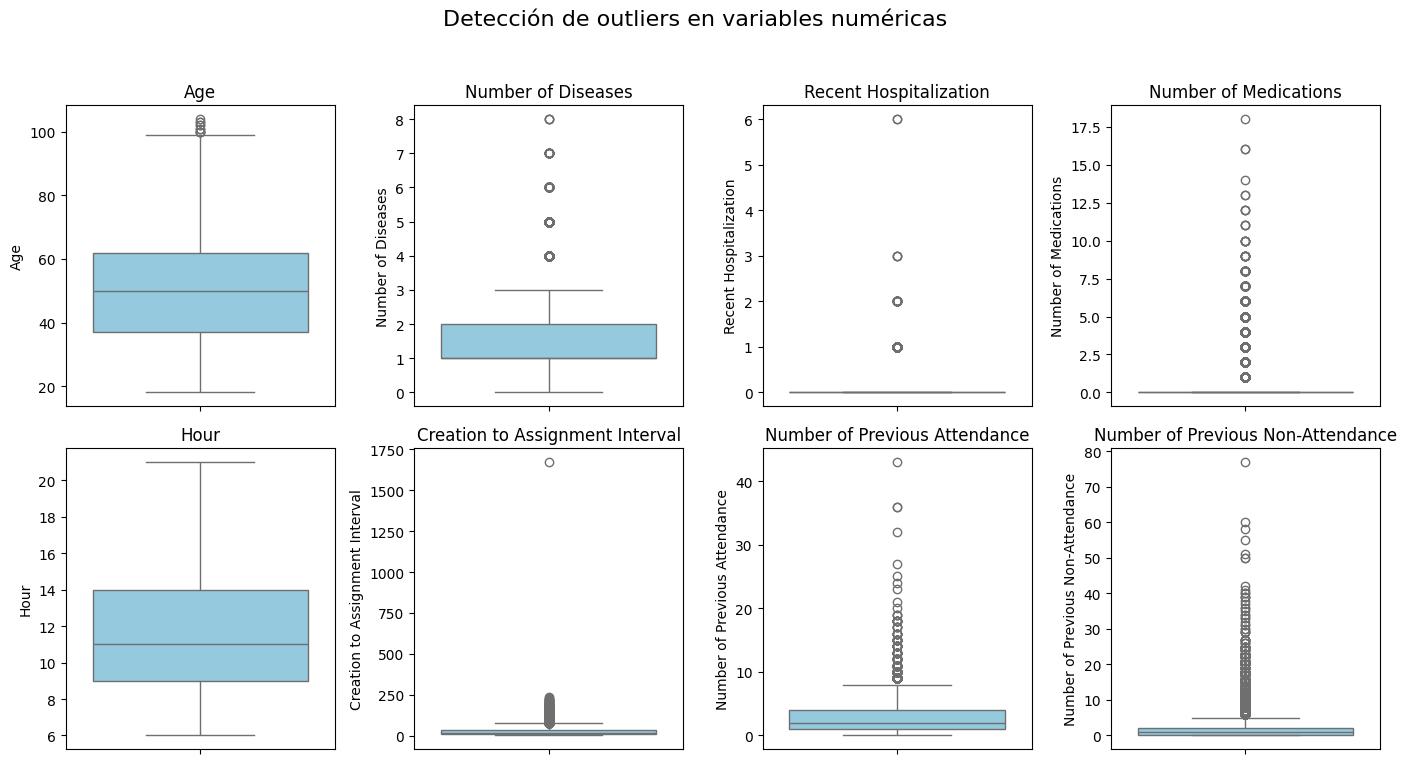

In [7]:
# Variables numéricas según tu descripción
df
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Boxplots para ver outliers
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_sin_errores_digitacion[col], color='skyblue')
    plt.title(col)
plt.suptitle("Detección de outliers en variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
condicion_outlier = {
    'Creation to Assignment Interval': (df_sin_errores_digitacion['Creation to Assignment Interval'] > 365),
}

count_invalid = 0

# Crear una máscara booleana general que marca los registros inválidos
mask_invalid = pd.Series(False, index=df_sin_errores_digitacion.index)

# Identificar registros inválidos según las reglas
for col, cond in condicion_outlier.items():
    invalidos = df_sin_errores_digitacion[cond]
    count_invalid += len(invalidos)
    mask_invalid = mask_invalid | cond  # combinar condiciones
    if len(invalidos) > 0:
        print(f"\n{len(invalidos)} valores inválidos en '{col}':")

print("\n-----------------------")
# Eliminar los registros inválidos del DataFrame
df_limpio = df_sin_errores_digitacion[~mask_invalid].copy()

print(f"\nTotal de registros antes: {len(df_sin_errores_digitacion)}")
print(f"Total de registros después de eliminar outliers: {len(df_limpio)}")
eliminados_outliers = len(df_sin_errores_digitacion) - len(df_limpio)
print(f"Registros eliminados: {eliminados_outliers}")


1 valores inválidos en 'Creation to Assignment Interval':

-----------------------

Total de registros antes: 18391
Total de registros después de eliminar outliers: 18390
Registros eliminados: 1


## Resumen Limpieza

In [ ]:
print(f'Total registros antes: {len(df)}')
print(f'Total registros después de limpieza: {len(df_limpio)}')
print(f'Total registros eliminados: {len(df)-len(df_limpio)}')
print(f'Porcentaje de registros eliminados: %{(len(df)-len(df_limpio))/len(df)*100}')

Total registros antes: 18587
Total registros después de limpieza: 18390
Total registros eliminados: 197
Porcentaje de registros eliminados: %1.0598805616828966


# EDA

### Distribución variables numéricas

<Figure size 1400x1000 with 0 Axes>

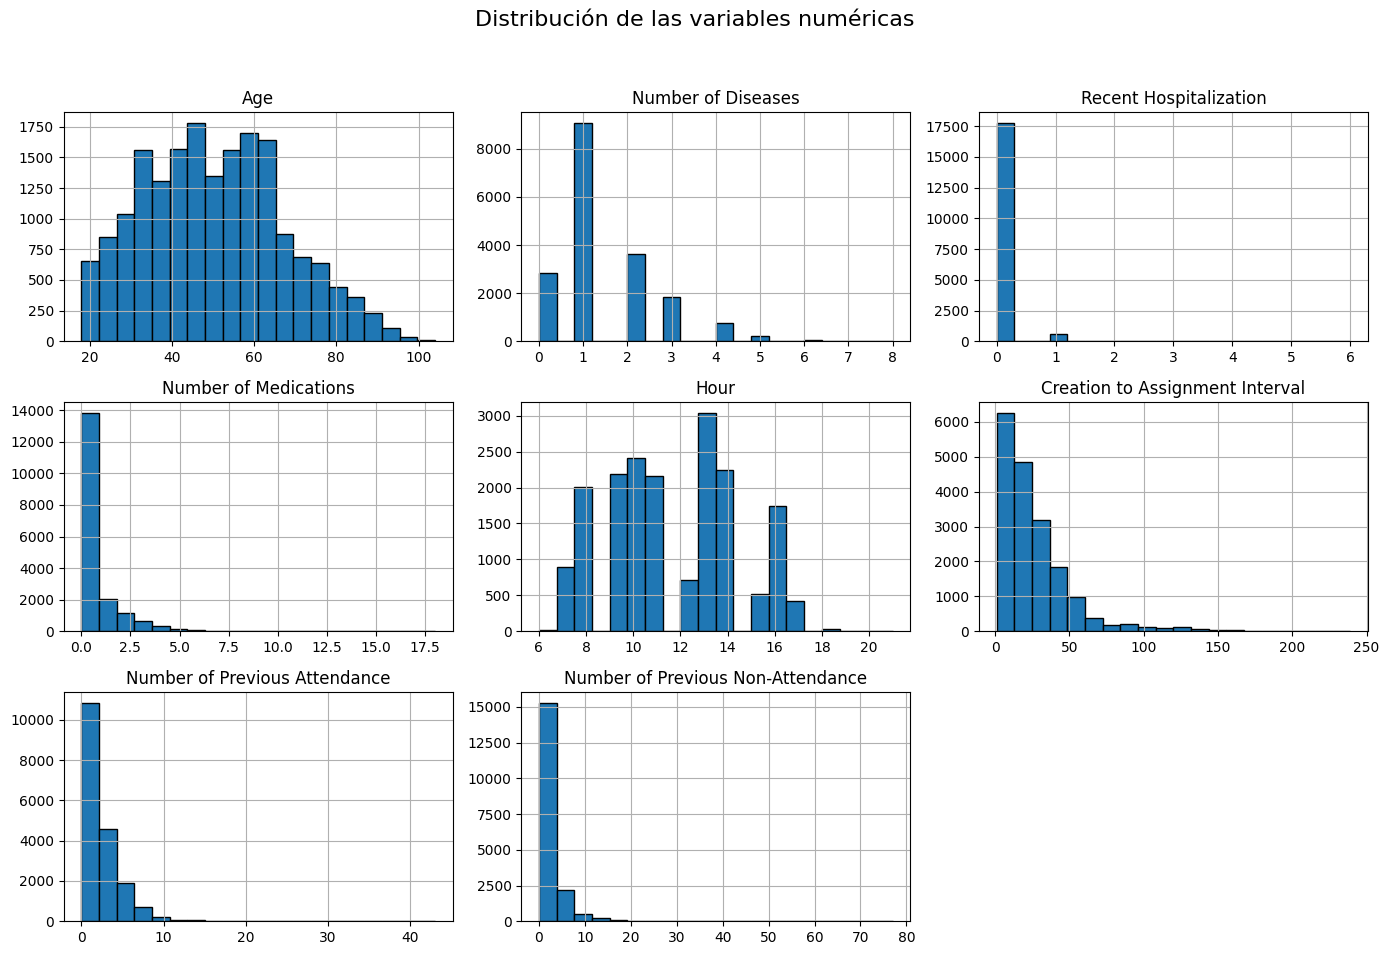

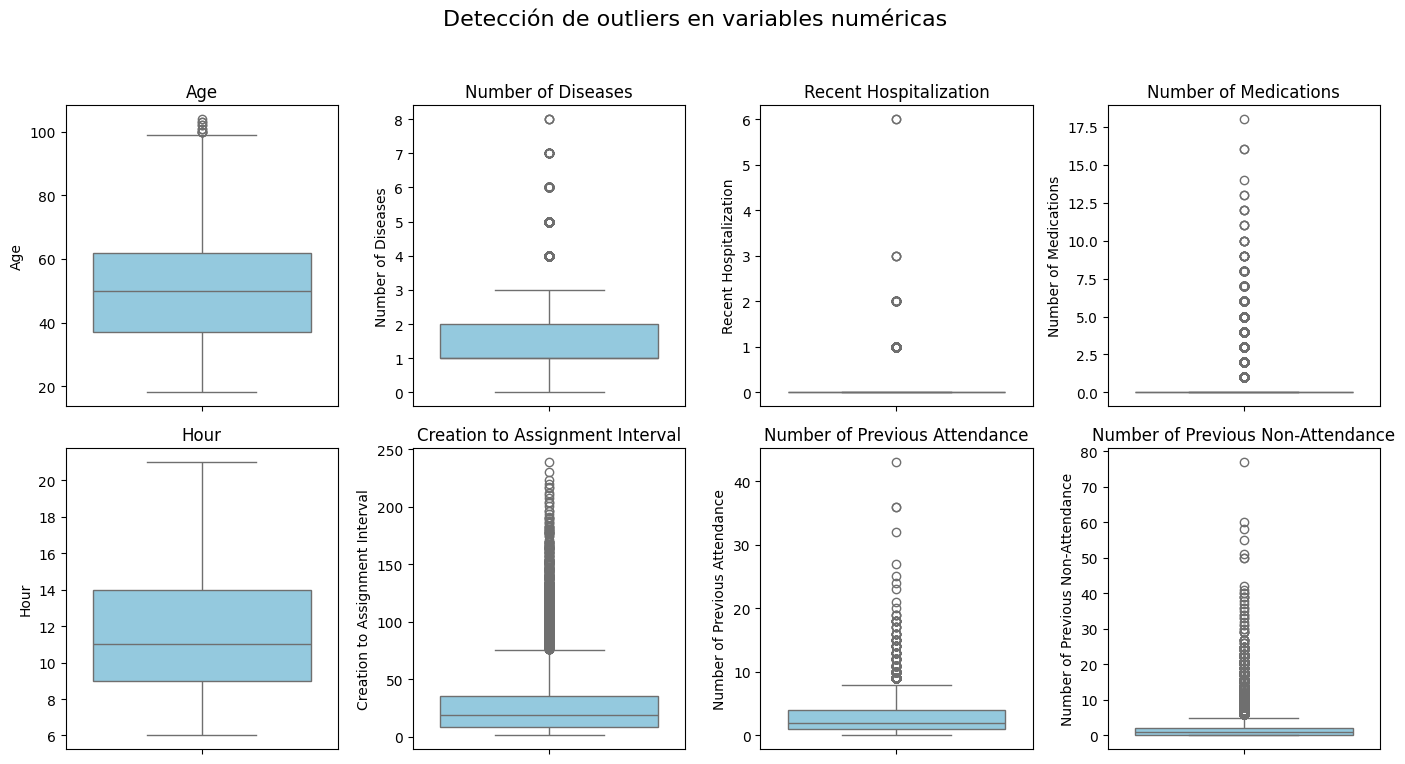

In [13]:
# Variables numéricas
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Histogramas
plt.figure(figsize=(14,10))
df_limpio[num_cols].hist(figsize=(14,10), bins=20, edgecolor='black')
plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Boxplots para ver outliers
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_limpio[col], color='skyblue')
    plt.title(col)
plt.suptitle("Detección de outliers en variables numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Distribución variables categóricas


 Frecuencia de variables categóricas:

--- Sex ---
Sex
0    11427
1     6930
2       33
Name: count, dtype: int64


C:\Users\samue\AppData\Local\Temp\ipykernel_21672\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


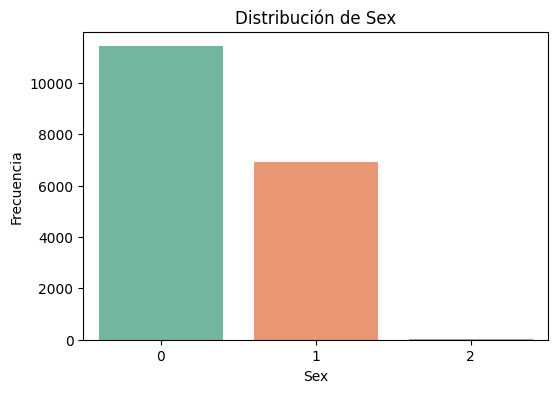


--- Insurance Type ---
Insurance Type
0      601
1     1670
2       42
3    15241
4      658
5       12
6        7
7      153
8        6
Name: count, dtype: int64


C:\Users\samue\AppData\Local\Temp\ipykernel_21672\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


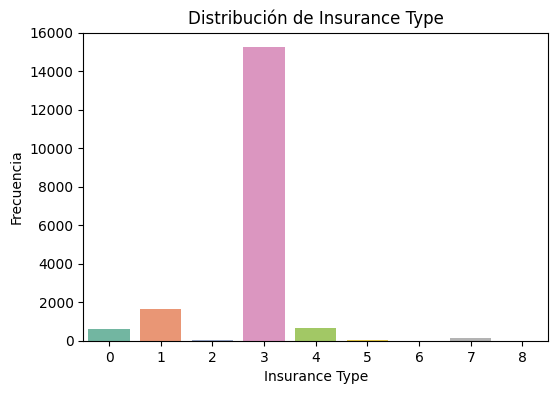


--- Day ---
Day
0    3287
1    2863
2    2638
3    2808
4    2320
5    2008
6    2466
Name: count, dtype: int64


C:\Users\samue\AppData\Local\Temp\ipykernel_21672\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


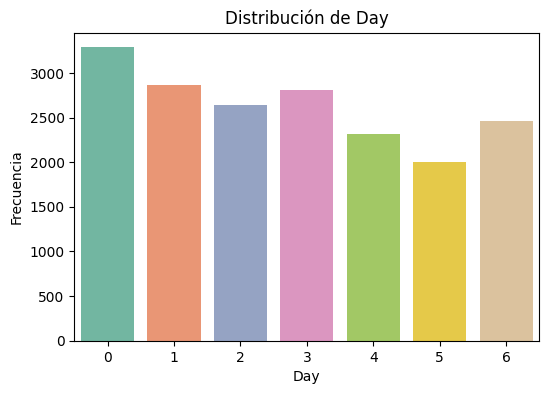

C:\Users\samue\AppData\Local\Temp\ipykernel_21672\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))



--- Month ---
Month
1     1191
2     1103
3     1392
4     1406
5     1743
6     1940
7     2209
8     3065
9     3166
10     378
11     406
12     391
Name: count, dtype: int64


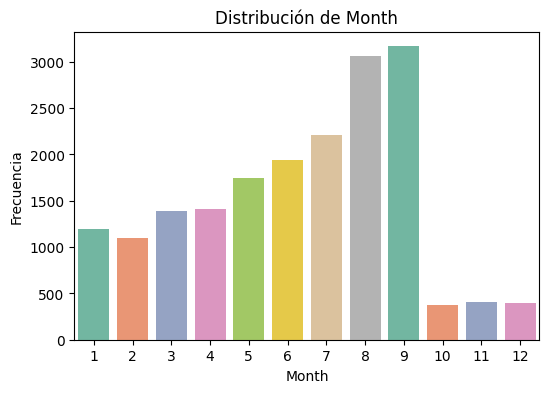


--- Appointment Type ---
Appointment Type
0    12114
1     6276
Name: count, dtype: int64


C:\Users\samue\AppData\Local\Temp\ipykernel_21672\581492274.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))


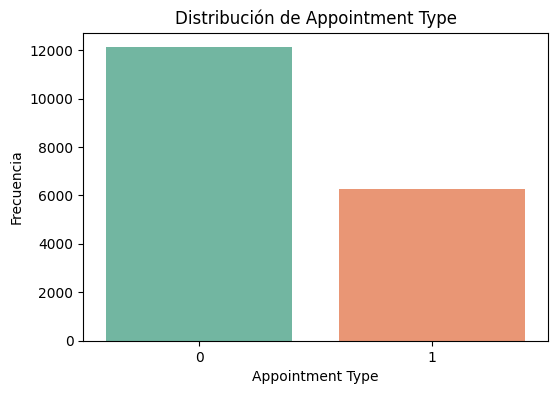

In [16]:
# Variables categóricas según tu descripción
cat_cols = ['Sex', 'Insurance Type', 'Day', 'Month', 'Appointment Type']

print("\n Frecuencia de variables categóricas:")

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_limpio[col].value_counts().sort_index())

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df_limpio, palette='Set2', order=sorted(df_limpio[col].unique()))
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

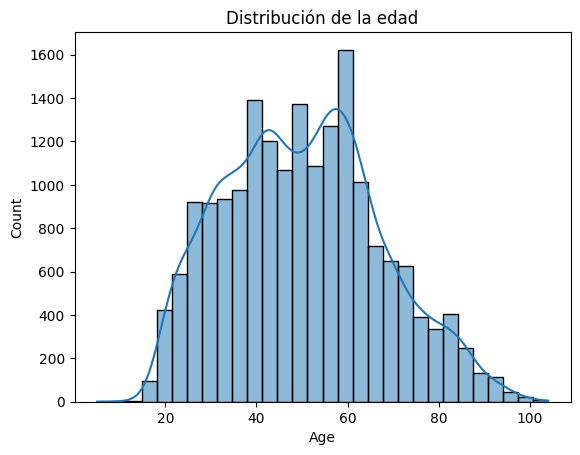

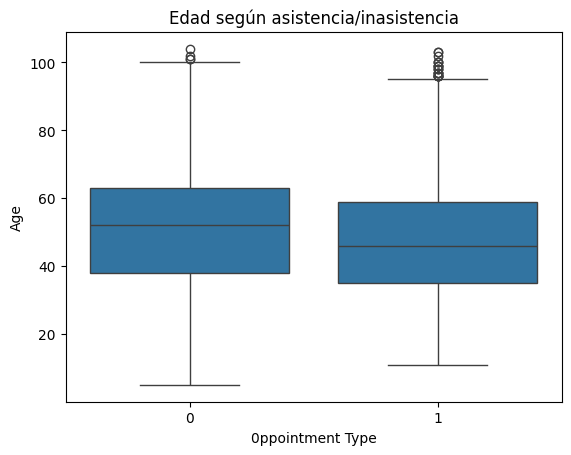

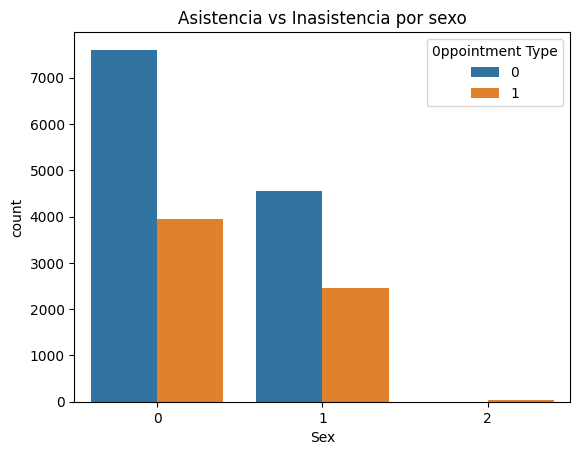

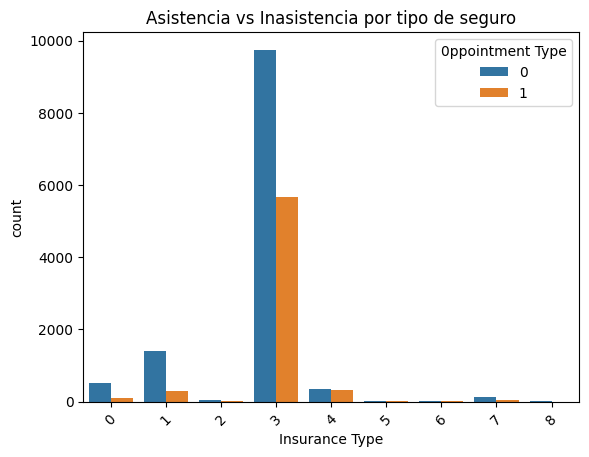

In [ ]:

# ===========================
#  Variables sociodemográficas
# ===========================

# Edad
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribución de la edad")
plt.show()

sns.boxplot(x='0ppointment Type', y='Age', data=df)
plt.title("Edad según asistencia/inasistencia")
plt.show()

# Sexo
sns.countplot(x="Sex", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia por sexo")
plt.show()

# Tipo de seguro
sns.countplot(x="Insurance Type", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia por tipo de seguro")
plt.xticks(rotation=45)
plt.show()

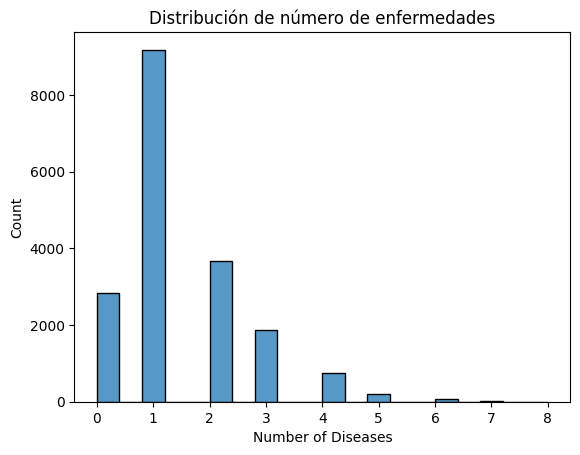

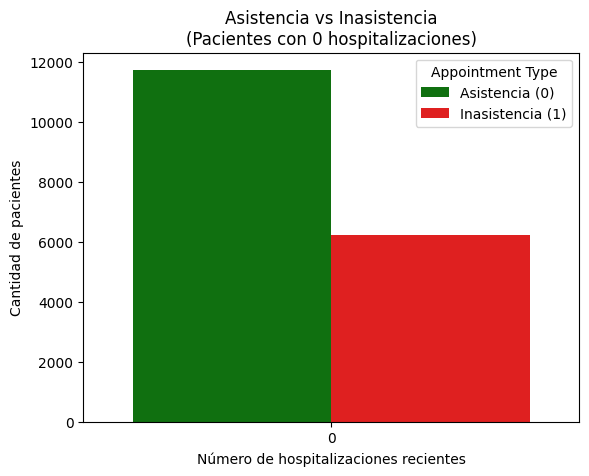

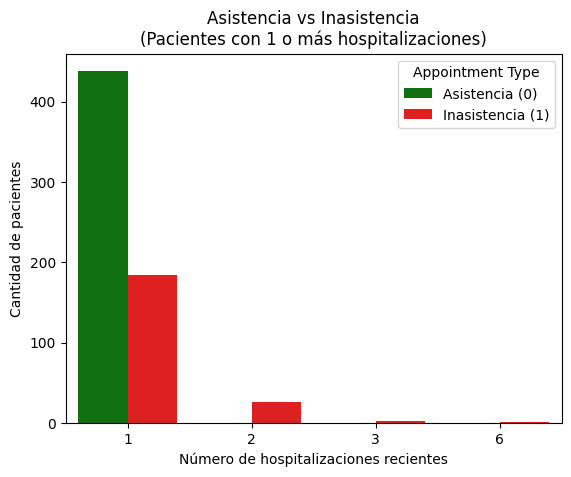

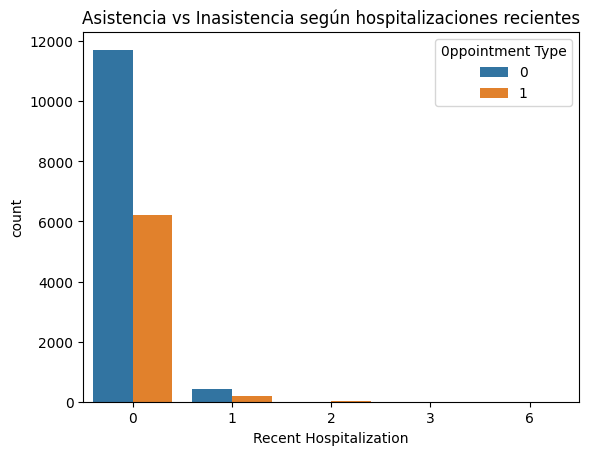

In [ ]:
# ===========================
#  Variables clínicas
# ===========================

# Número de enfermedades
sns.histplot(df['Number of Diseases'], bins=20, kde=False)
plt.title("Distribución de número de enfermedades")
plt.show()

# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 0 hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 1 o más hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()


# Hospitalización reciente
sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia según hospitalizaciones recientes")
plt.show()



C:\Users\alejo\AppData\Local\Temp\ipykernel_33312\1626566398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])


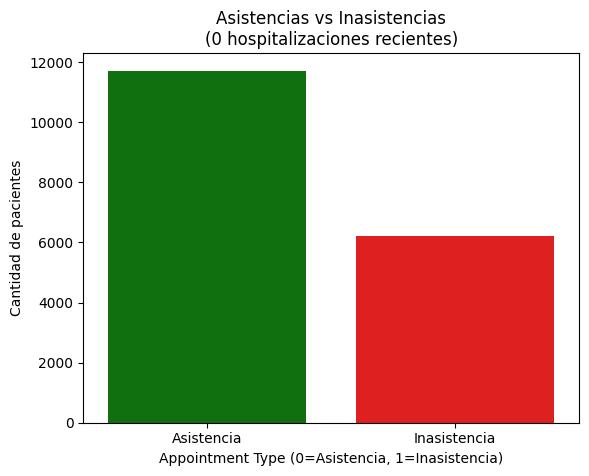

C:\Users\alejo\AppData\Local\Temp\ipykernel_33312\1626566398.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="0ppointment Type", data=subset_hosp, palette=["green", "red"])


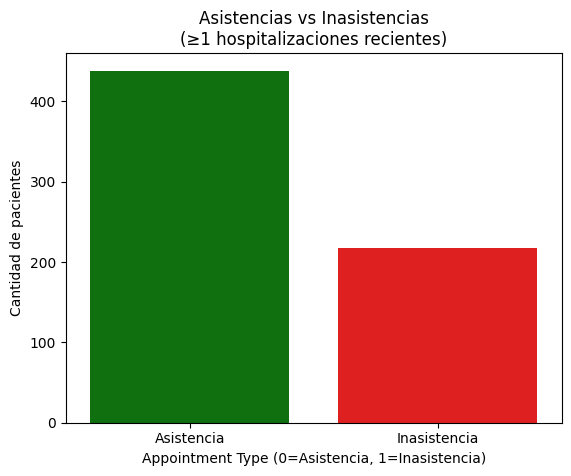

In [ ]:
# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(0 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="0ppointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(≥1 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()

## Matriz de Correlación


Matriz de correlación:


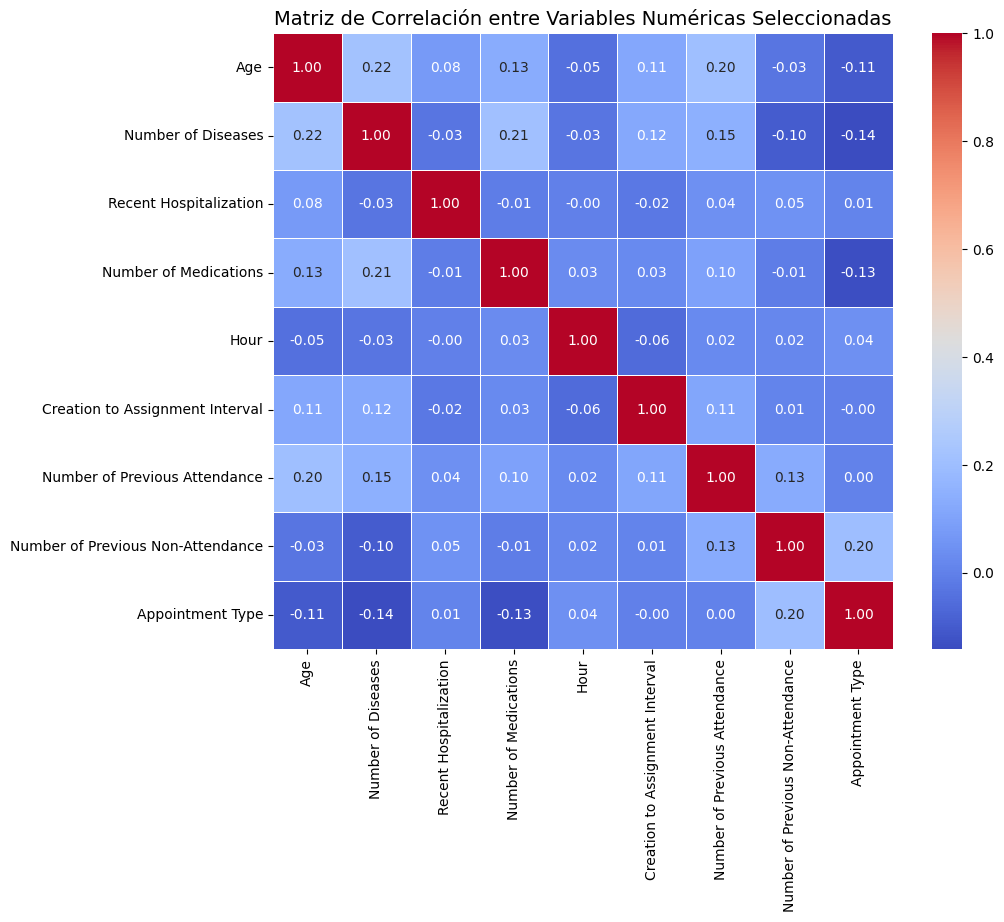


Correlación con la variable objetivo (Appointment Type):
Appointment Type                     1.000000
Number of Previous Non-Attendance    0.197838
Hour                                 0.042700
Recent Hospitalization               0.008235
Number of Previous Attendance        0.001388
Creation to Assignment Interval     -0.000684
Age                                 -0.105301
Number of Medications               -0.134646
Number of Diseases                  -0.141564
Name: Appointment Type, dtype: float64


In [ ]:
num_cols = [
    'Age', 'Number of Diseases', 'Recent Hospitalization',
    'Number of Medications', 'Hour',
    'Creation to Assignment Interval',
    'Number of Previous Attendance', 'Number of Previous Non-Attendance'
]

# Incluimos la variable objetivo para medir su correlación con las demás
cols_corr = num_cols + ['Appointment Type']

# Calcular la matriz de correlación solo con las columnas seleccionadas
corr_matrix = df_limpio[cols_corr].corr()

# Mostrar la matriz numérica
print("\nMatriz de correlación:")
# print(corr_matrix)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas Seleccionadas", fontsize=14)
plt.show()

# Correlación de cada variable con la variable objetivo
target_corr = corr_matrix["Appointment Type"].sort_values(ascending=False)
print("\nCorrelación con la variable objetivo (Appointment Type):")
print(target_corr)
